In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

# EDA

## Framing


**What type of problem is this — supervised /unsupervised? Classification, clustering,regression?**

In [144]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  float64
 1   name                            42234 non-null  object 
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  object 
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  object 
 6   host_identity_verified          42218 non-null  object 
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  object 
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  object 
 12  minimum_nights                  

We can see that this is regression problem, as we want to predict a future output value given some input value. The learning is supervised. The target value is `price` which is present in the training data set.

**How many columns are there in the training set?
How many in the test set? Where do they match /
mismatch? Which contain missing values?
How many rows are there in the training set?
How many in the test set? How many are usable
as is?**

In [145]:
print("Columns in training data:", len(train_df.columns))
print("Columns in test data:", len(test_df.columns))
print("Rows in training data:", len(train_df))
print("Rows in test data", len(test_df))
print("Columns different: ", set(train_df.columns).difference(set(test_df.columns)))
print("Training columns with missing data:", train_df.isnull().any().sum())
print("Test columns with missing data:", test_df.isnull().any().sum())
print("Usable as-is:", min(len(train_df.columns),len(test_df.columns)) - max(train_df.isnull().any().sum(), test_df.isnull().any().sum()))


Columns in training data: 36
Columns in test data: 35
Rows in training data: 42234
Rows in test data 8199
Columns different:  {'price'}
Training columns with missing data: 18
Test columns with missing data: 2
Usable as-is: 17


In [146]:
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  float64
 1   name                            42234 non-null  object 
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  object 
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  object 
 6   host_identity_verified          42218 non-null  object 
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  object 
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  object 
 12  minimum_nights                  

,id,host_id,host_total_listings_count,neighbourhood_group,latitude,longitude,minimum_nights,calculated_host_listings_count,availability_365,number_of_reviews_ltm,...,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,price
count,4.223400e+04,4.223400e+04,42218.000000,0.0,42234.000000,42234.000000,42234.000000,42234.000000,42234.000000,42234.000000,...,33099.000000,33099.000000,33098.000000,33098.000000,33097.000000,33098.000000,33097.000000,33097.00000,0.0,42234.000000
mean,8.993349e+17,2.583441e+08,101.437088,NaN,51.509859,-0.132020,5.073401,20.487735,214.048705,8.045698,...,1.289538,4.672812,4.706610,4.659316,4.778300,4.798594,4.733334,4.58664,NaN,166.242743
std,5.391873e+17,2.326461e+08,680.747344,NaN,0.047786,0.100010,18.588886,58.075589,121.665001,13.632750,...,1.409859,0.503092,0.490562,0.502755,0.437346,0.438992,0.410206,0.52088,NaN,98.380093
min,1.391300e+04,2.594000e+03,1.000000,NaN,51.295937,-0.496075,1.000000,1.000000,0.000000,0.000000,...,0.010000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,NaN,50.000000
25%,6.337215e+17,3.432110e+07,2.000000,NaN,51.487090,-0.192176,1.000000,1.000000,92.000000,0.000000,...,0.340000,4.570000,4.650000,4.550000,4.750000,4.780000,4.670000,4.50000,NaN,90.000000
50%,1.076795e+18,1.860463e+08,5.000000,NaN,51.513580,-0.135140,2.000000,3.000000,242.000000,2.000000,...,0.840000,4.820000,4.860000,4.800000,4.920000,4.950000,4.850000,4.71000,NaN,141.000000
75%,1.352515e+18,4.830355e+08,25.000000,NaN,51.536787,-0.073803,3.000000,14.000000,333.000000,10.000000,...,1.740000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.89000,NaN,215.000000
max,1.508964e+18,7.186905e+08,8769.000000,NaN,51.682630,0.275100,999.000000,500.000000,365.000000,246.000000,...,36.960000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,NaN,500.000000


In [147]:
test_df.info()
test_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              8199 non-null   float64
 1   name                            8199 non-null   object 
 2   host_id                         8199 non-null   int64  
 3   host_name                       8199 non-null   object 
 4   host_total_listings_count       8199 non-null   int64  
 5   host_has_profile_pic            8199 non-null   object 
 6   host_identity_verified          8199 non-null   object 
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   8199 non-null   object 
 9   latitude                        8199 non-null   float64
 10  longitude                       8199 non-null   float64
 11  room_type                       8199 non-null   object 
 12  minimum_nights                  81

,id,host_id,host_total_listings_count,neighbourhood_group,latitude,longitude,minimum_nights,calculated_host_listings_count,availability_365,number_of_reviews_ltm,...,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license
count,8.199000e+03,8.199000e+03,8199.000000,0.0,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,...,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,0.0
mean,8.111947e+17,2.401778e+08,54.689474,NaN,51.510278,-0.132649,4.259422,16.681303,201.765581,10.262349,...,33.849982,1.264060,4.663313,4.703457,4.655154,4.777879,4.793047,4.725021,4.580500,NaN
std,5.471469e+17,2.286321e+08,387.128267,NaN,0.046830,0.097168,16.877908,42.146775,119.914823,15.159978,...,60.421421,1.382557,0.528081,0.501325,0.516702,0.446540,0.456056,0.425987,0.538581,NaN
min,3.629900e+04,6.774000e+03,1.000000,NaN,51.297899,-0.495127,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.010000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,5.134037e+07,2.973693e+07,2.000000,NaN,51.487233,-0.191921,1.000000,1.000000,88.000000,1.000000,...,4.000000,0.330000,4.570000,4.640000,4.540000,4.750000,4.780000,4.660000,4.490000,NaN
50%,9.738647e+17,1.499759e+08,5.000000,NaN,51.513360,-0.134518,2.000000,3.000000,217.000000,5.000000,...,12.000000,0.820000,4.820000,4.850000,4.800000,4.910000,4.940000,4.840000,4.710000,NaN
75%,1.280213e+18,4.673870e+08,23.000000,NaN,51.535791,-0.074147,3.000000,13.000000,319.000000,13.000000,...,37.000000,1.710000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.890000,NaN
max,1.505850e+18,7.179293e+08,8769.000000,NaN,51.680130,0.278960,600.000000,500.000000,365.000000,390.000000,...,849.000000,17.130000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,NaN


**Is price normally distributed? What is the
median price? How are features distributed —
normally / not normally? How many unique values
does each non-numeric column (eg.
neighbourhood) have? How will you handle these
columns?**

*Unique Non-Numeric Values:*

In [148]:
for col in train_df.columns:
  if train_df.dtypes[col] not in ["float64", "int64"]:
    print("Unique {}: ".format(col), len(train_df[col].unique()))


Unique name:  41118
Unique host_name:  9091
Unique host_has_profile_pic:  3
Unique host_identity_verified:  3
Unique neighbourhood:  33
Unique room_type:  4
Unique amenities:  38642
Unique last_review:  1661


We will handle these columns by using one-hot encoding where the nuber of unique values is small enough, otherwise we will eliminate them.

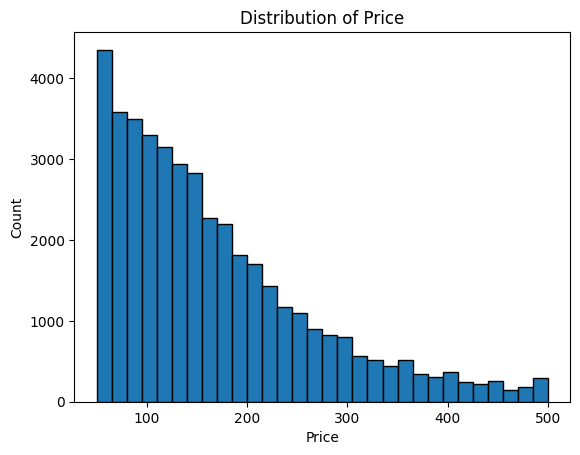

In [149]:
plt.hist(train_df['price'], bins=30, edgecolor='black')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

We can see that price is not normaly distributed. Lower prices are much more common.

In [150]:
print("Median price:", train_df['price'].median())

Median price: 141.0


**Is there a relationship between the price and
minimum_nights columns?**

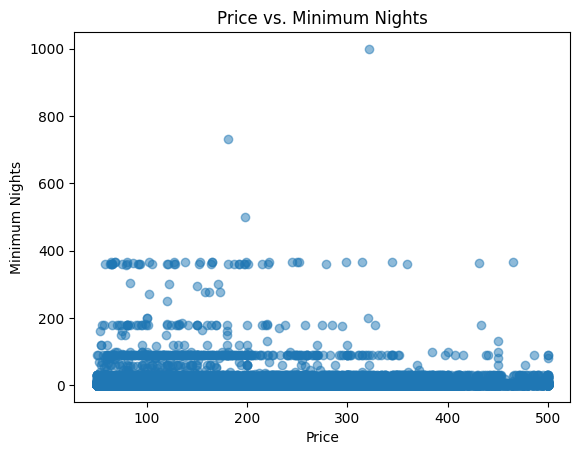

In [151]:
plt.scatter(train_df['price'], train_df['minimum_nights'], alpha=0.5)
plt.ylabel('Minimum Nights')
plt.xlabel('Price')
plt.title('Price vs. Minimum Nights')
plt.show()

There does not seem to be a strong relationship between the two

Even removing extreme values there is no real correlation

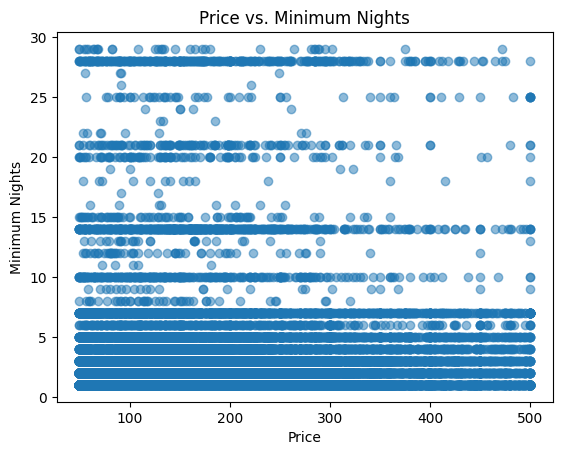

In [152]:
plot_df = train_df[train_df['minimum_nights'] < 30]
plt.scatter(plot_df['price'], plot_df['minimum_nights'], alpha=0.5)
plt.ylabel('Minimum Nights')
plt.xlabel('Price')
plt.title('Price vs. Minimum Nights')
plt.show()

# Data cleansing / Feature Engineering

### Removing Columns

In [153]:
train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

low_corr_cols=['id', 'name', 'host_id', 'host_name', 'host_total_listings_count', 'latitude', 'longitude', 'minimum_nights']
null_cols=['neighbourhood_group', 'license']

# Remove columns with no values
train_df = train_df.drop(columns=null_cols)
test_df = test_df.drop(columns=null_cols)

# Remove low correlation columns
train_df = train_df.drop(columns=low_corr_cols)
test_df = test_df.drop(columns=low_corr_cols)

train_df = train_df.dropna()

In [154]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33017 entries, 0 to 42233
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_has_profile_pic            33017 non-null  object 
 1   host_identity_verified          33017 non-null  object 
 2   neighbourhood                   33017 non-null  object 
 3   room_type                       33017 non-null  object 
 4   calculated_host_listings_count  33017 non-null  int64  
 5   availability_365                33017 non-null  int64  
 6   number_of_reviews_ltm           33017 non-null  int64  
 7   accommodates                    33017 non-null  int64  
 8   bathrooms                       33017 non-null  float64
 9   bedrooms                        33017 non-null  float64
 10  beds                            33017 non-null  float64
 11  amenities                       33017 non-null  object 
 12  availability_30                 33017

# Model preparation

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate

near_unique=['amenities', 'last_review']
train_df = train_df.drop(columns=near_unique)
train_df = pd.get_dummies(train_df, drop_first=True)
test_df = test_df.drop(columns=near_unique)
test_df = pd.get_dummies(test_df, drop_first=True)
train_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 33017 entries, 0 to 42233
Data columns (total 57 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   calculated_host_listings_count        33017 non-null  int64  
 1   availability_365                      33017 non-null  int64  
 2   number_of_reviews_ltm                 33017 non-null  int64  
 3   accommodates                          33017 non-null  int64  
 4   bathrooms                             33017 non-null  float64
 5   bedrooms                              33017 non-null  float64
 6   beds                                  33017 non-null  float64
 7   availability_30                       33017 non-null  int64  
 8   availability_60                       33017 non-null  int64  
 9   availability_90                       33017 non-null  int64  
 10  number_of_reviews                     33017 non-null  int64  
 11  reviews_per_month   

# Model

In [156]:
X_train, X_test, y_train, y_test = train_test_split(train_df.drop(columns=['price']), np.log1p(train_df['price']), test_size=0.25, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print("Root mean squared error:", root_mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

Root mean squared error: 0.3338198524326386
R2 Score: 0.6397573320381446


### Cross Validation

In [157]:
cv = KFold(n_splits=4, shuffle=True, random_state=42)

results = cross_validate(
    model, X_train, y_train, cv=cv,
    scoring=['r2', 'neg_root_mean_squared_error'],
    return_train_score=True
)

display(results)

{'fit_time': array([0.11405396, 0.11003542, 0.12035084, 0.08700991]),
 'score_time': array([0.00639105, 0.01058078, 0.00676966, 0.00621629]),
 'test_r2': array([0.62927147, 0.63932547, 0.64328774, 0.63597068]),
 'train_r2': array([0.64212249, 0.63875007, 0.63746724, 0.63993992]),
 'test_neg_root_mean_squared_error': array([-0.33653039, -0.33523939, -0.33306515, -0.33717629]),
 'train_neg_root_mean_squared_error': array([-0.33398758, -0.33443455, -0.33514411, -0.33378195])}

### Get coefficients

In [158]:
feature_columns = train_df.drop(columns=["price"]).columns.values
coef_table = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.coef_
})
coef_table = coef_table.sort_values(by=["coefficient"])

print("Intercept:", model.intercept_)
display(coef_table)
display(model)

Intercept: 3.6204886069179487


,feature,coefficient
55,room_type_Shared room,-0.618373
54,room_type_Private room,-0.493282
35,neighbourhood_Havering,-0.151631
22,neighbourhood_Bexley,-0.130687
48,neighbourhood_Sutton,-0.083572
18,review_scores_value,-0.082358
16,review_scores_communication,-0.081655
15,review_scores_checkin,-0.057304
24,neighbourhood_Bromley,-0.045628
20,host_identity_verified_t,-0.042210


LinearRegression()

### Plot Coefficients

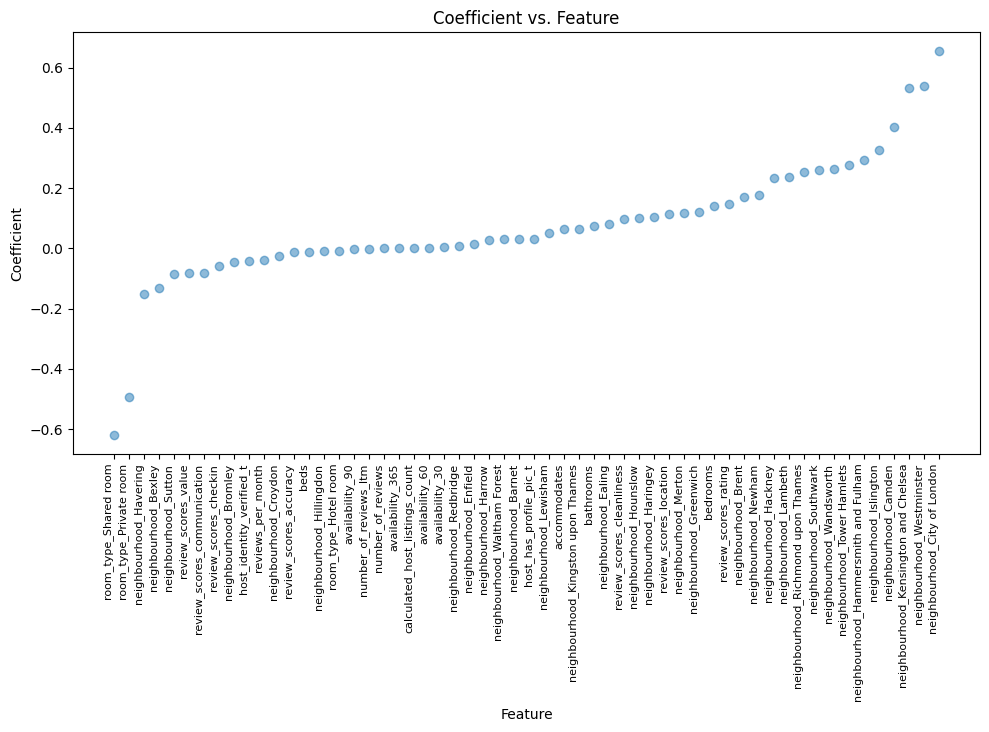

In [159]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.scatter(coef_table['feature'], coef_table['coefficient'], alpha=0.5)
plt.ylabel('Coefficient')
plt.xlabel('Feature')
plt.title('Coefficient vs. Feature')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()  # prevents labels from being clipped
plt.xticks(fontsize=8)
plt.show()

Apply model to actual test data

In [160]:
test_predictions = np.expm1(model.predict(test_df))
display(test_predictions)
pd.DataFrame(predictions).to_csv('A4_predictions_ShannonMante-Green.csv',
index=False)

array([195.08374005,  99.85062918, 174.21836343, ..., 151.5036732 ,
       204.3663235 , 120.51978236])

# Reflection Questions
1. Which features were most predictive of nightly price? Were the results what you
expected, or were you surprised by anything?
   - The most predictive features are room type and neighborhood. Specifically whether thr room is shared and if the accomodation is in a popular destination like London. I expected that the neighborhood would be a big factor in price, but I didn't expect the room type to be such a significant predictor. Specifically whether the room is shared or not is very predictive of price.
2. What does your model reveal about these Airbnb markets? For example: does
neighbourhood matter more than property size?
   - Yes, neighborhood matters much more than property size. Thinking about it a bit more it makes sense as AirBnB is mostly used by tourists who want to be close to popular destinations. Thus, supply and demand would dictate that the most popular destinations would be the most expensive.
3. What additional data would have improved your model? Name at least one variable not
present in the dataset that you believe would be a strong predictor of price, and explain
why.
   - If there were a good way to quantify distance from popular attractions, I think it would be a very strong predictor of price. The reasoning is the same as in #2. People looking for AirBnBs are most likely looking for someplace nearby a popular attraction.